In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
import pandas as pd

df = pd.read_json(
    "../data/raw/ember2018/train_features_3.jsonl",
    lines=True
)

print(df.shape)
df.head()

(129195, 14)


,sha256,md5,appeared,label,avclass,histogram,byteentropy,strings,general,header,section,imports,exports,datadirectories
0,f8598eb7e20219d05a293e69035dd3a92bc6036385e295...,6bcf7923383011a57053be0975a6feb7,2018-05,0,,"[3902082, 301420, 141502, 156599, 127672, 1201...","[2087753, 149975, 18586, 264, 1007, 515, 46, 3...","{'numstrings': 80864, 'avlength': 13.865341808...","{'size': 19281976, 'vsize': 19419136, 'has_deb...","{'coff': {'timestamp': 1526924646, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'WS2_32.dll': ['ordinal11', 'ordinal9', 'ordi...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
1,3187295b34b5e790e157c3f4ce2a3af1238f9163d10b4d...,f65e6467670855e8d649043425c9e68b,2018-05,-1,,"[161250, 19718, 10823, 9275, 8017, 10683, 7300...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 3702, 'avlength': 8.95299837925...","{'size': 1024504, 'vsize': 53706752, 'has_debu...","{'coff': {'timestamp': 1519838203, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'storport.sys': ['StorPortDebugPrint', 'StorP...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
2,9c6d75200a8d0932ca77f68d78f11b89b0a45441abb166...,e74fcfd1499a4f816a99d35e297cce63,2018-05,-1,,"[654635, 44778, 21304, 18433, 16595, 26599, 13...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 11438, 'avlength': 14.205717782...","{'size': 3086336, 'vsize': 3125248, 'has_debug...","{'coff': {'timestamp': 2832079844, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...",{'msvcp_win.dll': ['?xsgetn@?$basic_streambuf@...,"[RunDll32Main, ServiceMain, SvchostPushService...","[{'name': 'EXPORT_TABLE', 'size': 168, 'virtua..."
3,971ed2f22fe06fdc5d7e1b9ede84fe5e2a0b7417fd5109...,3a1625a94e8ac4cacc0dc57dfa4d5aeb,2018-05,0,,"[123120, 87203, 85302, 90064, 86900, 87839, 87...","[14336, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","{'numstrings': 107050, 'avlength': 5.687006071...","{'size': 23719387, 'vsize': 2150400, 'has_debu...","{'coff': {'timestamp': 1330111204, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'KERNEL32.dll': ['SetFileTime', 'CompareFileT...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
4,d0d4fc923108782eb324301c865f7ca6a2f9f08bfbb16f...,a2b4808fd5c43c7f9e5c80c683e732e1,2018-05,1,high,"[309507, 32472, 5208, 4711, 8383, 3714, 3751, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 4107, 'avlength': 77.1911370830...","{'size': 1583104, 'vsize': 1601536, 'has_debug...","{'coff': {'timestamp': 1510760912, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'KERNEL32.dll': ['Sleep', 'GetTickCount', 'In...",[??0?$_Hash@V?$_Umap_traits@V?$basic_string@DU...,"[{'name': 'EXPORT_TABLE', 'size': 297832, 'vir..."


In [3]:
df.tail()

,sha256,md5,appeared,label,avclass,histogram,byteentropy,strings,general,header,section,imports,exports,datadirectories
129190,2a1bccb53fbf1f71b3088cd8bfbf684061ebc724bddfe8...,5386817f649dc7e8c9ab0384fa6cb862,2018-06,0,,"[39175, 6414, 3182, 1742, 2283, 1297, 1113, 13...","[6136, 4, 1, 1, 2049, 1, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 1711, 'avlength': 16.7919345412...","{'size': 223360, 'vsize': 253952, 'has_debug':...","{'coff': {'timestamp': 1528369204, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'kernel32.dll': ['GetFileType', 'EnterCritica...","[__dbk_fcall_wrapper, dbkFCallWrapperAddr]","[{'name': 'EXPORT_TABLE', 'size': 112, 'virtua..."
129191,575b7f24873e2d96f51936ab29d1202f6c1274537ffcdc...,929db08c4a82151f555d4ec2ca8de5e2,2018-06,0,,"[2689, 478, 175, 282, 283, 148, 379, 105, 77, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 221, 'avlength': 21.40271493212...","{'size': 17664, 'vsize': 32768, 'has_debug': 0...","{'coff': {'timestamp': 1528467416, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...",{'mscoree.dll': ['_CorDllMain']},[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
129192,40765972b28d90d2e10f6495aac87d53a6cd3c1258c997...,7278b7c3feb4d88f760ec8ae0f55716d,2018-06,1,gandcrab,"[26275, 1898, 1126, 955, 1277, 707, 618, 640, ...","[2048, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 985, 'avlength': 13.12182741116...","{'size': 215040, 'vsize': 237568, 'has_debug':...","{'coff': {'timestamp': 1529276635, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'KERNEL32.dll': ['GlobalAlloc', 'LoadLibraryW...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
129193,3faedfe114deca889357fd10fb40b79ab0fe22e1e4df43...,acdadc8dc2fd4f1b0629ec3a662e1358,2018-06,-1,,"[4072, 1174, 1046, 1134, 1141, 1091, 1078, 112...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 1304, 'avlength': 5.62730061349...","{'size': 278016, 'vsize': 512000, 'has_debug':...","{'coff': {'timestamp': 1518110432, 'machine': ...","{'entry': 'UPX0', 'sections': [{'name': 'UPX0'...","{'KERNEL32.DLL': ['LoadLibraryA'], 'MSVBVM60.D...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
129194,d26b773b51f6b963d02b1a5b48466032fc4ad4010fe2dd...,0e578dd5896ea1d6a5535880f1e94d07,2018-06,1,vittalia,"[109407, 2557, 2363, 2421, 2696, 2255, 2268, 2...","[157647, 2, 0, 1, 0, 0, 0, 1, 2, 0, 0, 0, 1, 4...","{'numstrings': 2915, 'avlength': 6.95849056603...","{'size': 675328, 'vsize': 692224, 'has_debug':...","{'coff': {'timestamp': 1525252304, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...",{'KERNEL32.dll': ['GetNamedPipeClientComputerN...,[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 129195 entries, 0 to 129194
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   sha256           129195 non-null  str   
 1   md5              129195 non-null  str   
 2   appeared         129195 non-null  str   
 3   label            129195 non-null  int64 
 4   avclass          129195 non-null  str   
 5   histogram        129195 non-null  object
 6   byteentropy      129195 non-null  object
 7   strings          129195 non-null  object
 8   general          129195 non-null  object
 9   header           129195 non-null  object
 10  section          129195 non-null  object
 11  imports          129195 non-null  object
 12  exports          129195 non-null  object
 13  datadirectories  129195 non-null  object
dtypes: int64(1), object(9), str(4)
memory usage: 13.8+ MB


In [5]:
df.dtypes

sha256                str
md5                   str
appeared              str
label               int64
avclass               str
histogram          object
byteentropy        object
strings            object
general            object
header             object
section            object
imports            object
exports            object
datadirectories    object
dtype: object

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print(missing)

Series([], dtype: int64)


In [7]:
print(df["label"].value_counts())

label
 1    47309
 0    47004
-1    34882
Name: count, dtype: int64


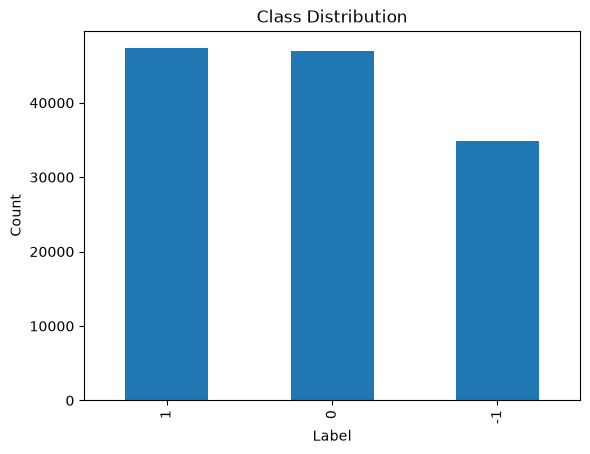

In [8]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [9]:
df.describe()

,label
count,129195.000000
mean,0.096188
std,0.791789
min,-1.000000
25%,-1.000000
50%,0.000000
75%,1.000000
max,1.000000


In [10]:
print(df.memory_usage(deep=True).sum() / 1024**2, "MB")

804.1077260971069 MB


In [11]:
print(df.columns.tolist())

['sha256', 'md5', 'appeared', 'label', 'avclass', 'histogram', 'byteentropy', 'strings', 'general', 'header', 'section', 'imports', 'exports', 'datadirectories']


In [12]:
numeric_cols = df.select_dtypes(include="number").columns
print(numeric_cols)

Index(['label'], dtype='str')


In [13]:
for col in df.columns:
    print(col)

sha256
md5
appeared
label
avclass
histogram
byteentropy
strings
general
header
section
imports
exports
datadirectories


In [14]:
import pandas as pd
import os

os.makedirs("../reports/summaries", exist_ok=True)

summary = pd.DataFrame({
    "Dataset": ["train_features_3"],
    "Rows": [df.shape[0]],
    "Columns": [df.shape[1]],
    "Missing Values": [df.isnull().sum().sum()],
    "Duplicate SHA256": [df["sha256"].duplicated().sum()],
    "Memory (MB)": [round(df.memory_usage(deep=True).sum()/(1024**2), 2)],
    "Malware Samples": [(df["label"] == 1).sum()],
    "Benign Samples": [(df["label"] == 0).sum()],
    "Unknown Samples": [(df["label"] == -1).sum()]
})

summary.to_csv("../reports/summaries/train_3_summary.csv", index=False)

print("Summary Saved!")

Summary Saved!
